# Email Spam Detection with Machine Learning

We've all been the recipient of spam emails before. Spam mail, or junk mail, is a type of email that is sent to a massive number of users at one time, frequently containing cryptic messages, scams, or phishing content.

## Objective

The objective of this project is to build an email spam detector using Python and machine learning to classify emails into spam and non-spam (ham).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

### Loading the Dataset

In [3]:
df = pd.read_csv('spam.csv', encoding='latin-1')

In [4]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


### Checking Dataset Information

In [5]:
print(df.info())

print(df.describe())

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB
None
          v1                      v2  \
count   5572                    5572   
unique     2                    5169   
top      ham  Sorry, I'll call later   
freq    4825                      30   

                                               Unnamed: 2  \
count                                                  50   
unique                                                 43   
top      bt not his girlfrnd... G o o d n i g h t . . .@"   
freq                                                    3   

                   Unnamed: 3 Unnamed: 4  
count            

### Dataset Columns

In [6]:
print(df.columns)

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')


### Cleaning the Dataset

In [7]:
# Keep only useful columns and rename them
df = df[['v1', 'v2']]

df.columns = ['Label', 'Message']

print(df.head())

  Label                                            Message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [8]:
# Check for missing values after cleaning
print(df.isnull().sum())

print("Dataset shape:", df.shape)

Label      0
Message    0
dtype: int64
Dataset shape: (5572, 2)


### Spam vs Ham Distribution

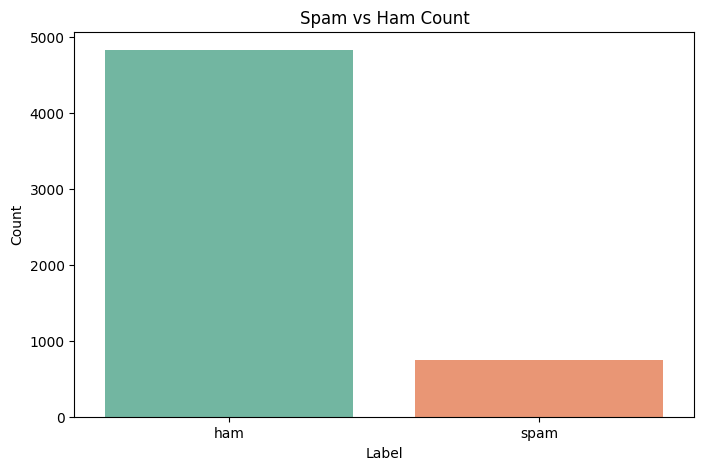

In [9]:
plt.figure(figsize=(8, 5))

sns.countplot(x='Label', data=df, palette='Set2')

plt.title("Spam vs Ham Count")

plt.xlabel("Label")

plt.ylabel("Count")

plt.show()

In [10]:
print(df['Label'].value_counts())

Label
ham     4825
spam     747
Name: count, dtype: int64


### Message Length Analysis

In [11]:
df['Message_Length'] = df['Message'].apply(len)

print(df.groupby('Label')['Message_Length'].mean())

Label
ham      71.023627
spam    138.866131
Name: Message_Length, dtype: float64


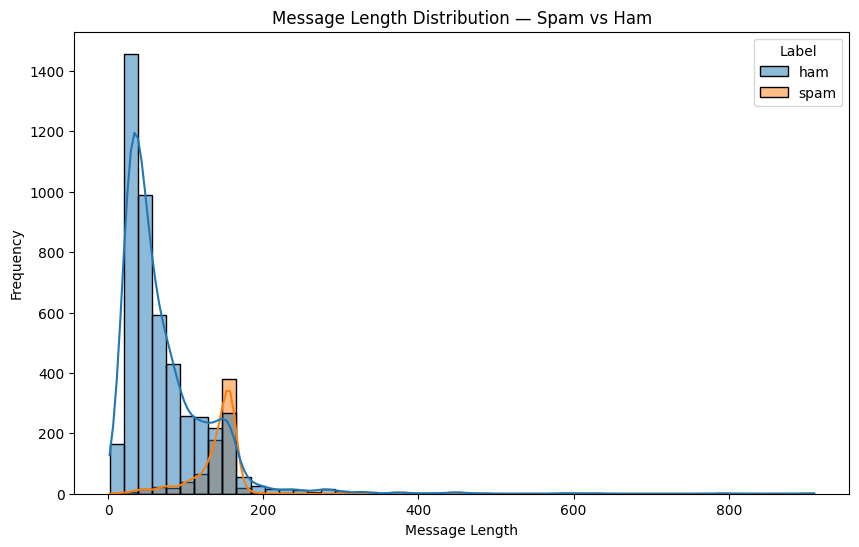

In [12]:
plt.figure(figsize=(10, 6))

sns.histplot(data=df, x='Message_Length', hue='Label', kde=True, bins=50)

plt.title("Message Length Distribution — Spam vs Ham")

plt.xlabel("Message Length")

plt.ylabel("Frequency")

plt.show()

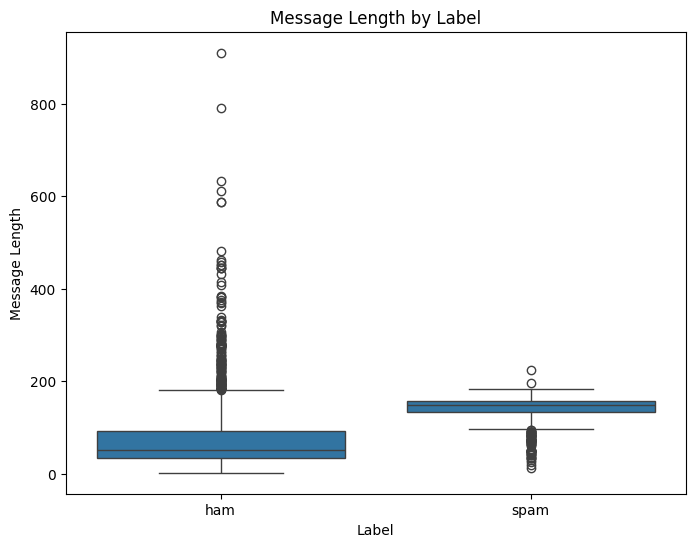

In [13]:
plt.figure(figsize=(8, 6))

sns.boxplot(x='Label', y='Message_Length', data=df)

plt.title("Message Length by Label")

plt.xlabel("Label")

plt.ylabel("Message Length")

plt.show()


### Data Preprocessing — Label Encoding

In [14]:
# Encode labels: spam = 1, ham = 0
df['Label_Encoded'] = df['Label'].map({'spam': 1, 'ham': 0})

print(df.head())

  Label                                            Message  Message_Length  \
0   ham  Go until jurong point, crazy.. Available only ...             111   
1   ham                      Ok lar... Joking wif u oni...              29   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...             155   
3   ham  U dun say so early hor... U c already then say...              49   
4   ham  Nah I don't think he goes to usf, he lives aro...              61   

   Label_Encoded  
0              0  
1              0  
2              1  
3              0  
4              0  


### Converting Text to Numerical Features using TF-IDF

In [16]:
tfidf = TfidfVectorizer(stop_words='english', max_features=3000)

X = tfidf.fit_transform(df['Message'])

y = df['Label_Encoded']

print("Feature matrix shape:", X.shape)

print("Target shape:", y.shape)

Feature matrix shape: (5572, 3000)
Target shape: (5572,)


### Splitting the Dataset into Train and Test Sets

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)

print("Testing set size:", X_test.shape)

Training set size: (4457, 3000)
Testing set size: (1115, 3000)


### Training — Naive Bayes Model

In [20]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_predictions = nb_model.predict(X_test)

print("Naive Bayes Model Trained Successfully")

Naive Bayes Model Trained Successfully


### Training — Logistic Regression Model

In [21]:
lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

print("Logistic Regression Model Trained Successfully")

Logistic Regression Model Trained Successfully


### Model Evaluation

In [22]:
print("=== Naive Bayes ===")
print("Accuracy:", round(accuracy_score(y_test, nb_predictions), 4))
print(classification_report(y_test, nb_predictions, target_names=['Ham', 'Spam']))

print()

print("=== Logistic Regression ===")
print("Accuracy:", round(accuracy_score(y_test, lr_predictions), 4))
print(classification_report(y_test, lr_predictions, target_names=['Ham', 'Spam']))

=== Naive Bayes ===
Accuracy: 0.9803
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       965
        Spam       1.00      0.85      0.92       150

    accuracy                           0.98      1115
   macro avg       0.99      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115


=== Logistic Regression ===
Accuracy: 0.9552
              precision    recall  f1-score   support

         Ham       0.95      1.00      0.97       965
        Spam       0.97      0.69      0.80       150

    accuracy                           0.96      1115
   macro avg       0.96      0.84      0.89      1115
weighted avg       0.96      0.96      0.95      1115



### Confusion Matrix — Naive Bayes

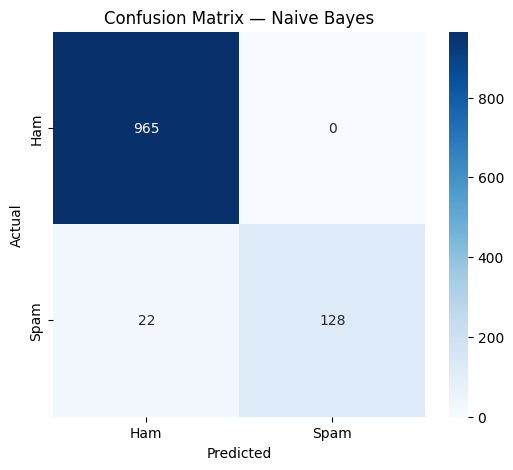

In [23]:
plt.figure(figsize=(6, 5))

sns.heatmap(confusion_matrix(y_test, nb_predictions), annot=True, fmt='d',
            cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])

plt.title("Confusion Matrix — Naive Bayes")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

### Confusion Matrix — Logistic Regression

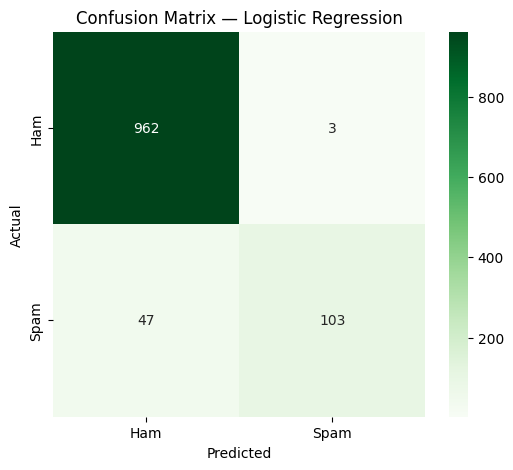

In [24]:
plt.figure(figsize=(6, 5))

sns.heatmap(confusion_matrix(y_test, lr_predictions), annot=True, fmt='d',
            cmap='Greens', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])

plt.title("Confusion Matrix — Logistic Regression")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()


### Testing the Model on a Custom Message

In [25]:
def predict_spam(message):
    msg_transformed = tfidf.transform([message])
    result = lr_model.predict(msg_transformed)[0]
    label = "SPAM" if result == 1 else "HAM (Not Spam)"
    print(f"Message: {message}")
    print(f"Prediction: {label}")
    print()

predict_spam("Congratulations! You have won a free lottery ticket. Call now to claim your prize.")

predict_spam("Hey, are we still meeting tomorrow for lunch?")

Message: Congratulations! You have won a free lottery ticket. Call now to claim your prize.
Prediction: SPAM

Message: Hey, are we still meeting tomorrow for lunch?
Prediction: HAM (Not Spam)



### Average Message Length

In [26]:
average_length = df['Message_Length'].mean()

print("Average Message Length:", round(average_length, 2), "characters")

Average Message Length: 80.12 characters


## Conclusion

The email spam dataset was successfully analyzed and used to train machine learning models. Two models were built — Naive Bayes and Logistic Regression. Both models achieved high accuracy in classifying emails as spam or ham. TF-IDF vectorization was used to convert text messages into numerical features. The project demonstrates how natural language processing and machine learning can be combined to build an effective spam detection system.